## **ASSIGNMENT 4**: KNN vs. Logistic Regression

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from collections import Counter
import time
from sklearn.preprocessing import OneHotEncoder

---

## **TASK  1**: Analysis on the **Iris dataset**

* Loading the `Iris` dataset

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

In [4]:
iris = pd.DataFrame(X, columns=iris.feature_names)
iris["species"] = y

In [5]:
iris.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### **Petal Width vs. Petal Length**: I'm choosing these features to predict the label because they cluster the data in the best way. In other words, the clearest differences between species can be observed by plotting these 2 features together.


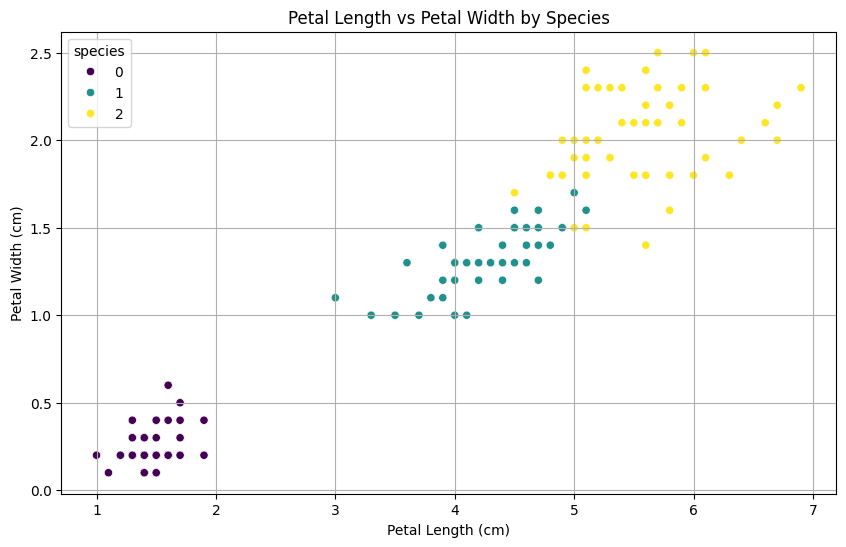

In [6]:
# scatter plot petal_length vs petal_width colored by species
plt.figure(figsize=(10,6))
sns.scatterplot(data=iris, x='petal length (cm)', y='petal width (cm)', hue='species', palette = 'viridis')
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.show()

For both methods used the features (petal width and petal length) will be rescaled to the range (0,1) using MinMaxScaler.

In [7]:
# standardizing the features that I will use
scaler = MinMaxScaler()
iris[['petal length (cm)', 'petal width (cm)']] = scaler.fit_transform(iris[['petal length (cm)', 'petal width (cm)']])

print(iris.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5           0.067797          0.041667   
1                4.9               3.0           0.067797          0.041667   
2                4.7               3.2           0.050847          0.041667   
3                4.6               3.1           0.084746          0.041667   
4                5.0               3.6           0.067797          0.041667   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


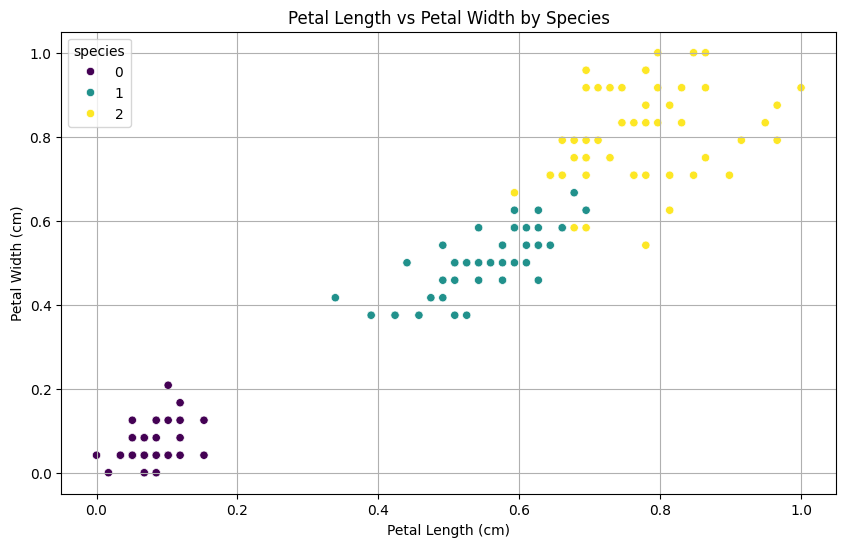

In [8]:
# scatter plot petal_length vs petal_width colored by species
plt.figure(figsize=(10,6))
sns.scatterplot(data=iris, x='petal length (cm)', y='petal width (cm)', hue='species', palette = 'viridis')
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True)
plt.show()

### 1. Algorithm for performing **KNN** on the **Iris Dataset**

For the KNN part I am using the code created in assignment 3.

* Manual model

In [9]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def manhattan_distance(p1, p2):
    return np.sum(np.abs(p1 - p2))

def bubble_sort(distances):
    n = len(distances)
    for i in range(n):
        for j in range(0, n-i-1):
            if distances[j][0] > distances[j+1][0]:
                distances[j], distances[j+1] = distances[j+1], distances[j]
    return distances

def majority_vote(distances, k):
    neighbors = [label for (_, label) in distances[:k]]
    vote_counts = Counter(neighbors)
    max_count = max(vote_counts.values())
    winners = [label for label, count in vote_counts.items() if count == max_count]
    
    if len(winners) == 1:
        return winners[0]
    else:
        for dist, label in distances[:k]:
            if label in winners:
                return label

def knn(x_test, X_train, y_train, k=1, distance_metric="euclidean"):
    distances=[]
    for i in range(len(X_train)):
        if distance_metric == "euclidean":
            distance = euclidean_distance(x_test, X_train[i])
        elif distance_metric == "manhattan":
            distance = manhattan_distance(x_test, X_train[i])
        else:
            raise ValueError("Unknown distance metric. Use 'euclidean' or 'manhattan'.")

        distances.append((distance, y_train[i]))

    distances = bubble_sort(distances)

    prediction = majority_vote(distances, k)

    return prediction


def loocv_knn(X, y, k=1, distance_metric="euclidean"):
    samples = X.shape[0]
    y_pred = []

    total_train_time = 0
    total_infer_time = 0
    
    for i in range(samples):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        x_test = X[i]

        # measuring training time
        start_train = time.time()
        stored_data = (X_train, y_train)
        total_train_time += time.time() - start_train

        # measuring inference time
        start_infer = time.time()
        pred = knn(x_test, X_train, y_train, k=k, distance_metric=distance_metric)
        total_infer_time += time.time() - start_infer
        y_pred.append(pred)

    return np.array(y), np.array(y_pred), total_train_time, total_infer_time

* Scikit model

In [10]:
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier

def sklearn_knn(X, y, k=1, distance_metric="euclidean"):
    loocv = LeaveOneOut()
    y_true, y_pred = [], []
    
    knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)
    
    total_train_time = 0
    total_infer_time = 0
    
    for train_index, test_index in loocv.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # measuring training time
        start_train = time.time()
        knn.fit(X_train, y_train)
        total_train_time += time.time() - start_train

        # measuring inference time
        start_infer = time.time()
        pred = knn.predict(X_test)
        total_infer_time += time.time() - start_infer

        y_true.append(y_test[0])
        y_pred.append(pred[0])
    
    
    return np.array(y_true), np.array(y_pred), total_train_time, total_infer_time


* Evaluation

In [11]:
def evaluate_model(y_true, y_pred, training_time, inference_time, average='macro'):
    accuracy = accuracy_score(y_true, y_pred) * 100
    print(f"Accuracy : {accuracy:.2f}%")

    if training_time is not None:
        print(f"Total Training Time: {training_time:.6f} seconds")

    if inference_time is not None:
        print(f"Total Inference Time: {inference_time:.6f} seconds")

    print("=================================")

### 2. Algorithm for performing **Logistic Regression** on the **Iris Dataset**

* Manual model

In [12]:
def one_hot_encode(y):
    encoder = OneHotEncoder(sparse_output=False)
    return encoder.fit_transform(y.reshape(-1, 1))

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def predict_manual(X, W, b):
    z = np.dot(X, W) + b
    probabilities = softmax(z)
    return np.argmax(probabilities, axis=1)

def logistic_regression(X_train, Y_train, learning_rate=0.01, iterations=100):
    r, c = X_train.shape
    no_classes = Y_train.shape[1]

    W = np.random.uniform(-1, 1, (c, no_classes))
    b = np.random.uniform(-1, 1, no_classes)

    for i in range(iterations):
        z = np.dot(X_train, W) + b
        probabilities = softmax(z)

        dW = (1/r) * np.dot(X_train.T, (probabilities - Y_train))
        db = (1/r) * np.sum(probabilities - Y_train, axis=0)

        W -= learning_rate * dW
        b -= learning_rate * db

    return W, b

def loocv_regression(X, y, y_original, learning_rate=0.01, iterations=100):
    samples = X.shape[0]
    y_pred = []

    total_train_time = 0
    total_infer_time = 0

    for i in range(samples):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(y, i, axis=0)
        X_test = X[i].reshape(1, -1)

        # measuring training time
        start_train = time.time()
        W, b = logistic_regression(X_train, Y_train, learning_rate=learning_rate, iterations=iterations)
        total_train_time += time.time() - start_train

        # measuring inference time
        start_infer = time.time()
        pred = predict_manual(X_test, W, b)[0]
        total_infer_time += time.time() - start_infer

        y_pred.append(pred)

    return np.array(y_original), np.array(y_pred), total_train_time, total_infer_time




* Scikit model

In [13]:
from sklearn.linear_model import LogisticRegression

def sklearn_regression(X, y, max_iter=1000):
    loocv = LeaveOneOut()
    y_true, y_pred = [], []

    total_train_time = 0
    total_infer_time = 0

    for train_index, test_index in loocv.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        regression = LogisticRegression(max_iter=max_iter)

        # measuring training time
        start_train = time.time()
        regression.fit(X_train, y_train)
        total_train_time += time.time() - start_train

        # measuring inference time
        start_infer = time.time()
        pred = regression.predict(X_test)
        total_infer_time += time.time() - start_infer

        y_true.append(y_test[0])
        y_pred.append(pred[0])

    return np.array(y_true), np.array(y_pred), total_train_time, total_infer_time


* Evaluation: I am using the same function I created in the KNN section for calculating the **accuracy**

---

#### **Applying the algorithms to the original Iris dataset**

---

In [14]:
X = iris[['petal length (cm)', 'petal width (cm)']].values
y = iris['species'].values

In [15]:
y_true, y_pred, training_time, inference_time = loocv_knn(X, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.67%
Total Training Time: 0.000071 seconds
Total Inference Time: 0.250232 seconds


In [16]:
y_encoded = one_hot_encode(y)
y_true, y_pred, training_time, inference_time = loocv_regression(X, y_encoded, y, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.00%
Total Training Time: 5.151666 seconds
Total Inference Time: 0.003935 seconds


In [17]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.67%
Total Training Time: 0.090420 seconds
Total Inference Time: 0.148679 seconds


In [18]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X, y, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.33%
Total Training Time: 1.638983 seconds
Total Inference Time: 0.038166 seconds


---

#### **Applying the algorithms to the reduced Iris dataset**

---

First we reduce the number of datapoints for all classes:

In [19]:
def reduce_all_classes(X, y, percentage):
    X_new = []
    y_new = []
    
    for cls in np.unique(y):
        indices = np.where(y == cls)[0]
        keep_n = int(len(indices) * (1 - percentage))
        indices_reduced = indices[:keep_n]  
        X_new.append(X[indices_reduced])
        y_new.append(y[indices_reduced])
    
    return np.vstack(X_new), np.concatenate(y_new)


* Reducing by 10%

In [20]:
X_reduced, y_reduced = reduce_all_classes(X, y, percentage=0.10)
y_reduced_encoded = one_hot_encode(y_reduced)

In [21]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.30%
Total Training Time: 0.000094 seconds
Total Inference Time: 0.264522 seconds


In [22]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 93.33%
Total Training Time: 6.197418 seconds
Total Inference Time: 0.004793 seconds


In [23]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.30%
Total Training Time: 0.062758 seconds
Total Inference Time: 0.113464 seconds


In [24]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 94.81%
Total Training Time: 1.125899 seconds
Total Inference Time: 0.029570 seconds


* Reducing by 20%

In [25]:
X_reduced, y_reduced = reduce_all_classes(X, y, percentage=0.20)
y_reduced_encoded = one_hot_encode(y_reduced)

In [26]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.83%
Total Training Time: 0.000078 seconds
Total Inference Time: 0.163724 seconds


In [27]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 94.17%
Total Training Time: 4.622388 seconds
Total Inference Time: 0.005598 seconds


In [28]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.83%
Total Training Time: 0.086916 seconds
Total Inference Time: 0.162583 seconds


In [29]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 94.17%
Total Training Time: 0.995462 seconds
Total Inference Time: 0.028306 seconds


* Reducing by 30%

In [30]:
X_reduced, y_reduced = reduce_all_classes(X, y, percentage=0.30)
y_reduced_encoded = one_hot_encode(y_reduced)

In [31]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.19%
Total Training Time: 0.000074 seconds
Total Inference Time: 0.126357 seconds


In [32]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 91.43%
Total Training Time: 4.102728 seconds
Total Inference Time: 0.003994 seconds


In [33]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.19%
Total Training Time: 0.043385 seconds
Total Inference Time: 0.080928 seconds


In [34]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 92.38%
Total Training Time: 0.308370 seconds
Total Inference Time: 0.013860 seconds


Now we reduce the number of datapoints only for one class at a time. I am going to demonstrate for class 2, for which I will vary the percentage of the reduction.

In [35]:
def reduce_one_class(X, y, percentage, class_to_reduce):
    indices = np.where(y == class_to_reduce)[0]
    other_indices = np.where(y != class_to_reduce)[0]
    
    keep_n = int(len(indices) * (1 - percentage))
    indices_reduced = indices[:keep_n] 
    
    final_indices = np.concatenate([indices_reduced, other_indices])
    
    return X[final_indices], y[final_indices]


* Reducing by 10%

In [36]:
X_reduced, y_reduced = reduce_one_class(X, y, percentage=0.10, class_to_reduce=2)
y_reduced_encoded = one_hot_encode(y_reduced)

In [37]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.55%
Total Training Time: 0.000058 seconds
Total Inference Time: 0.202088 seconds


In [38]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.17%
Total Training Time: 5.523621 seconds
Total Inference Time: 0.004427 seconds


In [39]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.55%
Total Training Time: 0.109047 seconds
Total Inference Time: 0.205523 seconds


In [40]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.17%
Total Training Time: 1.027437 seconds
Total Inference Time: 0.030070 seconds


* Reducing by 20%

In [41]:
X_reduced, y_reduced = reduce_one_class(X, y, percentage=0.20, class_to_reduce=2)
y_reduced_encoded = one_hot_encode(y_reduced)

In [42]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.43%
Total Training Time: 0.000140 seconds
Total Inference Time: 0.292791 seconds


In [43]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.71%
Total Training Time: 7.112367 seconds
Total Inference Time: 0.005561 seconds


In [44]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.43%
Total Training Time: 0.102848 seconds
Total Inference Time: 0.175301 seconds


In [45]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.71%
Total Training Time: 1.329558 seconds
Total Inference Time: 0.030130 seconds


* Reducing by 30%

In [46]:
X_reduced, y_reduced = reduce_one_class(X, y, percentage=0.30, class_to_reduce=2)
y_reduced_encoded = one_hot_encode(y_reduced)

In [47]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.30%
Total Training Time: 0.000105 seconds
Total Inference Time: 0.235766 seconds


In [48]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_reduced, y_reduced_encoded, y_reduced, 0.085, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 93.33%
Total Training Time: 5.915633 seconds
Total Inference Time: 0.005081 seconds


In [49]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_reduced, y_reduced, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 96.30%
Total Training Time: 0.064047 seconds
Total Inference Time: 0.118431 seconds


In [50]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_reduced, y_reduced, 1000)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 94.81%
Total Training Time: 1.147710 seconds
Total Inference Time: 0.027699 seconds


**Observations:** 
* **The KNN algorithm has a moch shorter training time (almost 0):** since it is a "lazy algorithm", it doesn't train, it just stores the data and then makes predictions on the spot; however, because of that reason, its inference time is longer.
* **The Logistic Regression has a much shorter inference time:** because it doesn't just store the data its training time is longer, but the inference itself is shorter.
* **Overall, KNN outperforms Logistic Regression:** this might be because they predict in different ways. While KNN bases its prediction on distances, Logistic Regression draws straight decision boundaries ("lines"). And because the 3 categories are not perfectly clustered in 3 definite groups and datapoints are mixed together in places (for example Versicolor and Virginica tend to overlap, and their boundary is not perfectly linear), the distance based approach works best (KNN).
* **As the number of points decreases in all classes, accuracy decreases:** less data makes both models worse. For KNN this is because each datapoint will now have less neighbours on which to base its prediction; For the Logistic Regression parameter estimation (weights) becomes less stable and variance increases leading to poorer performance.
* **As the number of points decreases in one class, accuracy decreases:** This is mostly affecting KNN as it works best on balanced datasets, as each class should have an equal number of neighbours to base its voting on. For Logistic Regression this is a problem because then the class with fewer datapoints will have a decreased weigth (will contribute less to the loss function) which leads to biased decision boundaries.

---

## **TASK  2**: Analysis on the **Digits dataset**

* Importing the `Digits` dataset

In [51]:
digits = load_digits()

In [52]:
X = digits.data
y = digits.target

* For original (normalised) pixel values

In [53]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

y_encoded = one_hot_encode(y)

In [54]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_scaled, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 98.83%
Total Training Time: 0.007222 seconds
Total Inference Time: 352.125128 seconds


In [55]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_scaled, y_encoded, y, 0.085, 100)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 47.47%
Total Training Time: 204.781457 seconds
Total Inference Time: 0.111655 seconds


In [56]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_scaled, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 98.83%
Total Training Time: 1.121518 seconds
Total Inference Time: 4.252893 seconds


In [57]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_scaled, y, 100)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 97.22%
Total Training Time: 469.410306 seconds
Total Inference Time: 0.499418 seconds


* Binary pixel values

In [58]:
X_binary = (X_scaled > 0.5).astype(int)

In [59]:
y_true, y_pred, training_time, inference_time = loocv_knn(X_binary, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.33%
Total Training Time: 0.010911 seconds
Total Inference Time: 593.601481 seconds


In [60]:
y_true, y_pred, training_time, inference_time = loocv_regression(X_binary, y_encoded, y, 0.085, 100)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 44.52%
Total Training Time: 272.527959 seconds
Total Inference Time: 0.133791 seconds


In [61]:
y_true, y_pred, training_time, inference_time = sklearn_knn(X_binary, y, k=5, distance_metric="euclidean")
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 95.38%
Total Training Time: 1.202529 seconds
Total Inference Time: 3.294397 seconds


In [62]:
y_true, y_pred, training_time, inference_time = sklearn_regression(X_binary, y, 100)
evaluate_model(y_true, y_pred, training_time, inference_time)

Accuracy : 92.88%
Total Training Time: 450.319391 seconds
Total Inference Time: 0.495847 seconds


* Adding Gussian noise

In [63]:
def add_gaussian_noise(X, mean=0, std=0.5):
    noise = np.random.normal(mean, std, X.shape)
    noisy = X + noise
    np.clip(noisy, 0, 1, out=noisy) 
    return noisy

In [64]:
noise_levels = [0.1, 0.2, 0.3]

noisy_datasets = {}
for std in noise_levels:
    noisy_datasets[f"Noisy (std={std})"] = add_gaussian_noise(X_scaled, std=std)


In [65]:
for name, X_noisy in noisy_datasets.items():
    print(f"\n=== {name} ===")
    
    y_true, y_pred, training_time, inference_time = loocv_knn(X_noisy, y, k=5, distance_metric="euclidean")
    evaluate_model(y_true, y_pred, training_time, inference_time)

    y_true, y_pred, training_time, inference_time = loocv_regression(X_noisy, y_encoded, y, learning_rate=0.085, iterations=100)
    evaluate_model(y_true, y_pred, training_time, inference_time)

    y_true, y_pred, training_time, inference_time = sklearn_knn(X_noisy, y, k=5, distance_metric="euclidean")
    evaluate_model(y_true, y_pred, training_time, inference_time)

    y_true, y_pred, training_time, inference_time = sklearn_regression(X_noisy, y, 100)
    evaluate_model(y_true, y_pred, training_time, inference_time)



=== Noisy (std=0.1) ===
Accuracy : 98.16%
Total Training Time: 0.012789 seconds
Total Inference Time: 416.190468 seconds
Accuracy : 42.18%
Total Training Time: 250.789436 seconds
Total Inference Time: 0.132993 seconds
Accuracy : 98.22%
Total Training Time: 1.263699 seconds
Total Inference Time: 2.688183 seconds
Accuracy : 95.33%
Total Training Time: 355.969145 seconds
Total Inference Time: 0.521968 seconds

=== Noisy (std=0.2) ===
Accuracy : 95.99%
Total Training Time: 0.016209 seconds
Total Inference Time: 543.637764 seconds
Accuracy : 33.39%
Total Training Time: 207.841049 seconds
Total Inference Time: 0.111484 seconds
Accuracy : 95.88%
Total Training Time: 1.022803 seconds
Total Inference Time: 1.902797 seconds
Accuracy : 92.26%
Total Training Time: 335.537955 seconds
Total Inference Time: 0.479759 seconds

=== Noisy (std=0.3) ===
Accuracy : 90.82%
Total Training Time: 0.013417 seconds
Total Inference Time: 462.412266 seconds
Accuracy : 28.05%
Total Training Time: 220.542330 second

**Observations:** 
* **When we binarize** the images a lot of information (shades of grey) that helped distinguish the digits before is now lost, therefore leading to a poor performance for both of the algorithms.
* **Adding Gaussian noise** introduces small intensity variations in the data, which is handled best by the KNN since it's a distance based algorithm, being though the reason for the slight decrease in the accuracy (compared with the original normalised values).